## 1. Dependencies

In [1]:
!pip install -q rdflib langchain-ollama langchain-community langchain-text-splitters chromadb pypdf requests beautifulsoup4 lxml langgraph


## 2. Loading the rdf data as an input knowledge graph

In [4]:
from pathlib import Path
from rdflib import Graph

_HERE = Path(__file__).parent if "__file__" in dir() else Path.cwd()
g = Graph()
g.parse(str(Path.home() / "Desktop" / "emdat_climate_events.ttl"), format="ttl")
print(f"Loaded {len(g)} triples")


Loaded 73781 triples


## 3. Defining the LLMs for each different task

In [5]:
from langchain_ollama import ChatOllama

# Main model — KG exploration, SPARQL querying, synthesis, feedback
llm = ChatOllama(model="gpt-oss:120b-cloud", temperature=1, num_ctx=4096)

# Router — lightweight classifier, no tools
llm_router = ChatOllama(model="gpt-oss:120b-cloud", temperature=0, num_ctx=4096)

# RAG model — semantic search distillation
llm_rag_model = ChatOllama(model="gpt-oss:120b-cloud", temperature=0, num_ctx=4096)


## 4. RAG — Loading the knowledge sources as pdfs and websites

In [6]:
import os, functools, hashlib, shutil
from pathlib import Path
from typing import Iterable, Optional
from urllib.parse import urlparse

import requests
from bs4 import BeautifulSoup

from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader, WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_ollama import OllamaEmbeddings

# ---------------------------------------------------------------------------
# RAG source configuration
# ---------------------------------------------------------------------------
# Put here any list of report/article URLs you want to index. The example below
# is a World Weather Attribution article URL of the kind required by the workflow.
WEBSITE_URLS = ['https://www.worldweatherattribution.org/southeast-brazil-drought-2014-2015/', 'https://www.worldweatherattribution.org/the-role-of-climate-change-in-the-2015-2017-drought-in-the-western-cape-of-south-africa/', 'https://www.worldweatherattribution.org/ethiopia-drought-2015/', 'https://www.worldweatherattribution.org/uks-storm-desmond-december-2015/', 'https://www.worldweatherattribution.org/chennai-floods-december-2015/', 'https://www.worldweatherattribution.org/kenya-drought-2016/', 'https://www.worldweatherattribution.org/india-heat-wave-2016/', 'https://www.worldweatherattribution.org/european-rainstorms-may-2016/', 'https://www.worldweatherattribution.org/louisiana-downpours-august-2016/', 'https://www.worldweatherattribution.org/somalia-drought-2016-2017/', 'https://www.worldweatherattribution.org/se-europe-cold-january-2017/', 'https://www.worldweatherattribution.org/analysis/cold-spells/', 'https://www.worldweatherattribution.org/extreme-heat-australia-february-2017/', 'https://www.worldweatherattribution.org/european-heat-june-2017/', 'https://www.worldweatherattribution.org/bangladesh-floods-august-2017/', 'https://www.worldweatherattribution.org/hurricane-harvey-august-2017/', 'https://www.worldweatherattribution.org/the-stormy-month-of-january-2018-over-western-europe/', 'https://www.worldweatherattribution.org/a-quick-look-at-the-extreme-rainfall-in-japan/', 'https://www.worldweatherattribution.org/hurricane-florence-september-2018/', 'https://www.worldweatherattribution.org/human-contribution-to-record-breaking-june-2019-heatwave-in-france/', 'https://www.worldweatherattribution.org/rapid-attribution-of-the-extreme-rainfall-in-texas-from-tropical-storm-imelda/', 'https://www.worldweatherattribution.org/climate-change-added-4bn-to-damage-of-japans-typhoon-hagibis/', 'https://www.worldweatherattribution.org/human-induced-climate-change-compounded-by-socio-economic-water-stressors-increased-severity-of-drought-in-syria-iraq-and-iran/', 'https://www.worldweatherattribution.org/human-induced-climate-change-increased-drought-severity-in-southern-horn-of-africa/', 'https://www.worldweatherattribution.org/western-north-american-extreme-heat-virtually-impossible-without-human-caused-climate-change/', 'https://www.worldweatherattribution.org/climate-change-increased-rainfall-associated-with-tropical-cyclones-hitting-highly-vulnerable-communities-in-madagascar-mozambique-malawi/', 'https://www.worldweatherattribution.org/climate-change-made-devastating-early-heat-in-india-and-pakistan-30-times-more-likely/', 'https://www.worldweatherattribution.org/climate-change-exacerbated-rainfall-causing-devastating-flooding-in-eastern-south-africa/', 'https://www.worldweatherattribution.org/climate-change-exacerbated-heavy-rainfall-leading-to-large-scale-flooding-in-highly-vulnerable-communities-in-west-africa/', 'https://www.worldweatherattribution.org/climate-change-increased-heavy-rainfall-hitting-vulnerable-communities-in-eastern-northeast-brazil/', 'https://www.worldweatherattribution.org/climate-change-likely-increased-extreme-monsoon-rainfall-flooding-highly-vulnerable-communities-in-pakistan/', 'https://www.worldweatherattribution.org/without-human-caused-climate-change-temperatures-of-40c-in-the-uk-would-have-been-extremely-unlikely/', 'https://www.worldweatherattribution.org/climate-change-not-el-nino-main-driver-of-exceptional-drought-in-highly-vulnerable-amazon-river-basin/', 'https://www.worldweatherattribution.org/the-role-of-climate-change-in-extreme-rainfall-associated-with-cyclone-gabrielle-over-aotearoa-new-zealands-east-coast/', 'https://www.worldweatherattribution.org/climate-change-more-than-doubled-the-likelihood-of-extreme-fire-weather-conditions-in-eastern-canada/', 'https://www.worldweatherattribution.org/limited-net-role-for-climate-change-in-heavy-spring-rainfall-in-emilia-romagna/', 'https://www.worldweatherattribution.org/limited-data-prevent-assessment-of-role-of-climate-change-in-deadly-floods-affecting-highly-vulnerable-communities-around-lake-kivu/', 'https://www.worldweatherattribution.org/extreme-heat-in-north-america-europe-and-china-in-july-2023-made-much-more-likely-by-climate-change/', 'https://www.worldweatherattribution.org/climate-change-indian-ocean-dipole-compounding-natural-hazards-and-high-vulnerability-increased-severity-of-flooding-in-the-horn-of-africa/', 'https://www.worldweatherattribution.org/climate-change-increased-heavy-precipitation-associated-with-impactful-storm-bettina-over-black-sea/', 'https://www.worldweatherattribution.org/el-nino-key-driver-of-drought-in-highly-vulnerable-southern-african-countries/', 'https://www.worldweatherattribution.org/reducing-vulnerability-and-improved-land-management-needed-with-increasing-heavy-rainfall-in-mindanao-island-southern-philippines-2/', 'https://www.worldweatherattribution.org/despite-known-coastal-cooling-trend-risk-of-deadly-wildfires-in-central-chile-increasing-with-changing-land-management-in-a-warming-climate/', 'https://www.worldweatherattribution.org/urban-planning-at-the-heart-of-increasingly-severe-east-african-flood-impacts-in-a-warming-world/', 'https://www.worldweatherattribution.org/increasing-april-may-rainfall-el-nino-and-high-vulnerability-behind-deadly-flooding-in-afghanistan-pakistan-and-iran/', 'https://www.worldweatherattribution.org/heavy-precipitation-hitting-vulnerable-communities-in-the-uae-and-oman-becoming-an-increasing-threat-as-the-climate-warms/', 'https://www.worldweatherattribution.org/climate-change-made-the-floods-in-southern-brazil-twice-as-likely/', 'https://www.worldweatherattribution.org/mixed-rainfall-trends-highlight-the-importance-of-climate-adaptation-in-coastal-new-south-wales/', 'https://www.worldweatherattribution.org/extreme-heat-killing-more-than-100-people-in-mexico-hotter-and-much-more-likely-due-to-climate-change/', 'https://www.worldweatherattribution.org/conflict-poverty-and-water-management-issues-exposing-vulnerable-communities-in-africa-to-extreme-floods-that-are-now-common-events-because-of-climate-change/', 'https://www.worldweatherattribution.org/deadly-mediterranean-heatwave-would-not-have-occurred-without-human-induced-climate-change/']

# Optional local PDFs. Leave empty if the RAG knowledge base should be built only
# from URLs.
PDF_PATHS = []

# Chroma root directory. A source-specific subdirectory is created automatically,
# so changing WEBSITE_URLS/PDF_PATHS builds or loads the correct vector DB instead
# of silently reusing an index created for a different source list.
_CHROMA_ROOT = str(Path.home() / "Desktop" / "climate_rag_db")

# Set to True when you want to force a fresh crawl/re-index of the configured URLs.
_FORCE_REBUILD_RAG = False

_HTTP_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (compatible; ClimateRAGBot/1.0; "
        "+https://www.worldweatherattribution.org/)"
    )
}


def _normalise_urls(urls: Iterable[str]) -> list[str]:
    """Validate, strip and de-duplicate URL strings while preserving order."""
    seen = set()
    clean_urls = []
    for raw_url in urls:
        url = str(raw_url).strip()
        if not url:
            continue
        parsed = urlparse(url)
        if parsed.scheme not in {"http", "https"} or not parsed.netloc:
            raise ValueError(f"Invalid URL: {raw_url!r}")
        if url not in seen:
            seen.add(url)
            clean_urls.append(url)
    return clean_urls


def configure_rag_sources(
    urls: Optional[Iterable[str]] = None,
    pdf_paths: Optional[Iterable[str]] = None,
    *,
    force_rebuild: bool = False,
) -> None:
    """Update the RAG knowledge-base sources and clear the retriever cache.

    Example:
        configure_rag_sources([
            "https://www.worldweatherattribution.org/climate-change-made-the-floods-in-southern-brazil-twice-as-likely/",
            "https://www.worldweatherattribution.org/another-report-url/",
        ], force_rebuild=True)

    Run this before invoking the graph if you want to index a different list of
    URLs without editing the notebook cell itself.
    """
    global WEBSITE_URLS, PDF_PATHS, _FORCE_REBUILD_RAG
    if urls is not None:
        WEBSITE_URLS = _normalise_urls(urls)
    if pdf_paths is not None:
        PDF_PATHS = [str(Path(p).expanduser()) for p in pdf_paths if str(p).strip()]
    _FORCE_REBUILD_RAG = bool(force_rebuild)
    _get_retriever.cache_clear()


def _source_signature() -> str:
    """Return a stable hash for the currently configured source list."""
    payload = "\n".join(["URL:" + u for u in _normalise_urls(WEBSITE_URLS)] +
                        ["PDF:" + str(Path(p).expanduser()) for p in PDF_PATHS])
    return hashlib.sha1(payload.encode("utf-8")).hexdigest()[:12]


def _rag_chroma_dir() -> str:
    return str(Path(_CHROMA_ROOT) / _source_signature())


def _extract_main_text_from_html(html: str, url: str) -> tuple[str, str]:
    """Extract readable article text from a webpage, with WWA-style pages in mind."""
    soup = BeautifulSoup(html, "lxml")

    for tag in soup(["script", "style", "noscript", "svg", "form", "header", "footer", "nav"]):
        tag.decompose()

    title = ""
    if soup.title and soup.title.string:
        title = soup.title.string.strip()

    # Prefer article/main content. World Weather Attribution report pages normally
    # expose the useful text inside article/main-like containers.
    main = soup.find("article") or soup.find("main")
    if main is None:
        main = soup.find("div", class_=lambda c: c and any(
            token in " ".join(c if isinstance(c, list) else [c]).lower()
            for token in ["content", "entry", "post", "article"]
        ))
    if main is None:
        main = soup.body or soup

    # Remove common non-content elements that may still be nested in the main area.
    for tag in main.find_all(["aside", "button", "form"]):
        tag.decompose()

    parts = []
    for node in main.find_all(["h1", "h2", "h3", "p", "li", "blockquote", "figcaption"]):
        text = " ".join(node.get_text(" ", strip=True).split())
        if len(text) >= 25:
            parts.append(text)

    text = "\n".join(parts)
    return title, text


def _load_url(url: str) -> Document:
    """Load one URL as a LangChain Document with source metadata."""
    try:
        response = requests.get(url, headers=_HTTP_HEADERS, timeout=30)
        response.raise_for_status()
        title, text = _extract_main_text_from_html(response.text, url)
        if len(text) < 500:
            # Fallback to LangChain's generic loader if custom extraction is too thin.
            docs = WebBaseLoader(url).load()
            if docs and docs[0].page_content.strip():
                doc = docs[0]
                doc.metadata.setdefault("source", url)
                doc.metadata.setdefault("title", title or url)
                return doc
            raise ValueError("extracted text was too short")
        return Document(
            page_content=f"Title: {title}\nURL: {url}\n\n{text}",
            metadata={"source": url, "title": title, "source_type": "webpage"},
        )
    except Exception as exc:
        raise RuntimeError(f"Failed to load {url}: {exc}") from exc


def _load_configured_documents() -> list[Document]:
    """Load all configured PDFs and webpages into LangChain Documents."""
    all_docs = []

    for p in PDF_PATHS:
        path = str(Path(p).expanduser())
        if os.path.exists(path):
            pdf_docs = PyPDFLoader(path).load()
            for d in pdf_docs:
                d.metadata.setdefault("source", path)
                d.metadata.setdefault("source_type", "pdf")
            all_docs.extend(pdf_docs)
        else:
            print(f"[RAG] WARNING: {path} not found; skipping PDF.")

    for url in _normalise_urls(WEBSITE_URLS):
        try:
            doc = _load_url(url)
            all_docs.append(doc)
            print(f"[RAG] Loaded URL: {url} ({len(doc.page_content):,} characters)")
        except Exception as exc:
            print(f"[RAG] WARNING: {exc}")

    if not all_docs:
        raise ValueError("No RAG documents were loaded. Check WEBSITE_URLS/PDF_PATHS and network access.")
    return all_docs


@functools.lru_cache(maxsize=1)
def _get_retriever():
    embeddings = OllamaEmbeddings(model="nomic-embed-text")
    chroma_dir = _rag_chroma_dir()

    if _FORCE_REBUILD_RAG and os.path.exists(chroma_dir):
        print(f"[RAG] Force rebuild requested; deleting {chroma_dir}")
        shutil.rmtree(chroma_dir)

    if os.path.exists(chroma_dir) and os.listdir(chroma_dir):
        print(f"[RAG] Loading existing Chroma DB for source set {_source_signature()}...")
        return Chroma(
            persist_directory=chroma_dir,
            embedding_function=embeddings,
        ).as_retriever(search_type="mmr", search_kwargs={"k": 5, "fetch_k": 20})

    print(f"[RAG] Building Chroma DB for {len(WEBSITE_URLS)} URL(s) and {len(PDF_PATHS)} PDF(s)...")
    all_docs = _load_configured_documents()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1200,
        chunk_overlap=180,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    splits = splitter.split_documents(all_docs)
    print(f"[RAG] {len(all_docs)} source document(s) -> {len(splits)} chunk(s)")

    vs = Chroma.from_documents(splits, embeddings, persist_directory=chroma_dir)
    if hasattr(vs, "persist"):
        vs.persist()
    return vs.as_retriever(search_type="mmr", search_kwargs={"k": 5, "fetch_k": 20})


USER_AGENT environment variable not set, consider setting it to identify your requests.


In [7]:
len(WEBSITE_URLS)

51

## 5. Defining the tools as functions

In [8]:
from langchain.tools import tool

# ── KG exploration tools ───────────────────────────────────────────────────

@tool
def list_classes(limit: int = 50) -> list:
    """Return RDF classes used in the knowledge graph."""
    results = g.query(f"SELECT DISTINCT ?c WHERE {{ ?s rdf:type ?c }} LIMIT {limit}")
    return [str(r[0]) for r in results]

@tool
def list_predicates(limit: int = 50) -> list:
    """Return predicates present in the knowledge graph."""
    results = g.query(f"SELECT DISTINCT ?p WHERE {{ ?s ?p ?o }} LIMIT {limit}")
    return [str(r.p) for r in results]

@tool
def get_class_properties(class_name: str) -> list:
    """Return predicates used by instances of a given class (e.g. 'ssn:Observation')."""
    cn = f"<{class_name}>" if class_name.startswith("http") else class_name
    results = g.query(f"SELECT DISTINCT ?p WHERE {{ ?s rdf:type {cn} ; ?p ?o }}")
    return [str(r.p) for r in results]

@tool
def sample_instances(class_name: str, limit: int = 10) -> list:
    """Return sample instance URIs for a given class."""
    cn = f"<{class_name}>" if class_name.startswith("http") else class_name
    results = g.query(f"SELECT DISTINCT ?s WHERE {{ ?s rdf:type {cn} }} LIMIT {limit}")
    return [str(r.s) for r in results]

@tool
def describe_entity(entity_uri: str) -> list:
    """Return all predicate-object pairs for a given entity URI."""
    results = g.query(f"SELECT ?p ?o WHERE {{ <{entity_uri}> ?p ?o }} LIMIT 50")
    return [{"predicate": str(r.p), "object": str(r.o)} for r in results]

# ── SPARQL execution tool ──────────────────────────────────────────────────

@tool
def run_sparql(query: str) -> list:
    """Execute a SPARQL SELECT query against the knowledge graph."""
    try:
        return [dict(row.asdict()) for row in g.query(query)]
    except Exception as e:
        return [{"error": str(e)}]

# ── RAG tool ──────────────────────────────────────────────────────────────

@tool
def semantic_search(question: str) -> str:
    """Semantic search over the configured URL/PDF RAG knowledge base."""
    try:
        docs = _get_retriever().invoke(question)
        if not docs:
            return "No relevant documents found."
        return "\n\n".join(
            f"SOURCE: {d.metadata.get('source', '?')}\n"
            f"TITLE: {d.metadata.get('title', '')}\n"
            f"PASSAGE:\n{d.page_content}"
            for d in docs
        )
    except Exception as e:
        return f"Error: {e}"


## 6. State, system prompts and tool bindings

In [9]:
from typing import Literal
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

_RDF_SCHEMA = """
Allowed prefixes:
@prefix aemet: <http://aemet.linkeddata.es/ontology/> .
@prefix clasik: <https://example.org/clasik#> .
@prefix geo1: <http://www.w3.org/2003/01/geo/wgs84_pos#> .
@prefix gn: <http://www.geonames.org/ontology#> .
@prefix qudt: <http://qudt.org/schema/qudt/> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix sorelsc: <http://sweetontology.net/relaSci/> .
@prefix soteria: <https://soteria-public.pages.sintef.no/soteria_ontology_documentation#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

The main node of the knowledge graph is an event, which is an instance of the class irdr:ClimateEvent. 
Each event is linked to a country URI through the gn:locatedIn property, which is described by a string through
the property gn:name. Each event is linked to its provinces through the property irdr:isInProvince. 
Each event is linked to a start date and an end date through the properties soteria:startDate and soteria:endDate.

Each event is related to an impact through the sorelsc:hasImpact property. Each impact 
is characterized as related to deaths through the property irdr:deaths, to people affected through the 
property irdr:peopleAffected, to people injured through the property irdr:injured and 
to economic loss through the property irdr:economicDamage.

Each event is characterized with a Disaster Type through the property irdr:hasDisasterType,
with a Disaster Subtype through the property irdr:hasDisasterSubtype, and with a Disaster
Subgroup with the property irdr:hasDisasterSubgroup.

"""

# ── Hard call-count limits (enforced in condition functions) ──────────────
MAX_EXPLORE_CALLS = 6   # max tool calls inside kg_explore loop
MAX_QUERY_CALLS   = 4   # max run_sparql attempts inside kg_query loop
MAX_RAG_CALLS     = 2   # max semantic_search calls inside rag loop

KG_EXPLORE_SYS = SystemMessage(content=f"""
You are a KG exploration agent. Tools: list_classes, list_predicates,
get_class_properties, sample_instances, describe_entity.
DO NOT call run_sparql.

IMPORTANT: You have at most {MAX_EXPLORE_CALLS} tool calls total. Be efficient:
  1. list_classes (once)
  2. list_predicates (once)
  3. get_class_properties for the single most relevant class (once)
  4. sample_instances for that class (once)
  5. describe_entity for ONE instance (once)
Stop immediately after step 5 and emit your EXPLORATION SUMMARY — do NOT
repeat any tool unless you got an error. Never call the same tool twice.
{_RDF_SCHEMA}
""")

KG_QUERY_SYS = SystemMessage(content=f"""
You are a SPARQL writer/executor. Only tool: run_sparql.
You have at most {MAX_QUERY_CALLS} attempts. Use the EXPLORATION SUMMARY to
build a correct SELECT query on the first try. If it returns no results,
fix capitalisation/URI patterns and retry — but stop after {MAX_QUERY_CALLS}
attempts regardless. No markdown/backticks in query strings.
Emit a natural-language summary once you have a valid result (or after
exhausting retries, summarise what you found or why the query failed).
{_RDF_SCHEMA}
""")

RAG_SYS = SystemMessage(content=f"""
You are a RAG agent. Only tool: semantic_search.
Call semantic_search at most {MAX_RAG_CALLS} time(s). Use a specific,
targeted query; do not repeat with near-identical queries.
Retrieve relevant passages from the configured URL/PDF vector database.
When summarising, cite the source URL(s) returned by semantic_search and
separate report evidence from your own reasoning.
""")

class AgentState(MessagesState):
    order:           Literal["kg_first", "rag_first"]
    explore_summary: str
    sparql_result:   str
    rag_result:      str
    final_answer:    str
    feedback_result: Literal["positive", "negative"]
    feedback_count:  int
    # ── per-run tool-call counters (reset on retry) ──
    explore_call_count: int
    query_call_count:   int
    rag_call_count:     int

explore_tools = [list_classes, list_predicates, get_class_properties, sample_instances, describe_entity]
query_tools   = [run_sparql]
rag_tools     = [semantic_search]

llm_explore = llm.bind_tools(explore_tools)
llm_query   = llm.bind_tools(query_tools)
llm_rag     = llm_rag_model.bind_tools(rag_tools)


## 7. Defining the functions in each graph node

In [10]:
import time
from langgraph.prebuilt import ToolNode
from langchain_core.messages import AIMessage, ToolMessage

EXPLORE_HISTORY_WINDOW = 4
RAG_HISTORY_WINDOW     = 4   # reduced from 6

def _trim(msgs, window):
    """Keep first message + most recent `window` messages."""
    return msgs if len(msgs) <= window + 1 else [msgs[0]] + msgs[-window:]

def _last_ai(msgs):
    """Most recent non-tool-calling AI message content."""
    return next((m.content for m in reversed(msgs)
                 if isinstance(m, AIMessage) and m.content
                 and not getattr(m, "tool_calls", None)), "")

def _invoke(llm_bound, msgs, retries=3, wait=5):
    """Retry wrapper for transient cloud errors."""
    for i in range(retries):
        try:
            return llm_bound.invoke(msgs)
        except Exception as e:
            if i == retries - 1: raise
            print(f"[Retry {i+1}/{retries}] {e} — waiting {wait}s...")
            time.sleep(wait)

# ── Router ─────────────────────────────────────────────────────────────────

ROUTER_SYS = """Route the question to the best knowledge source first.
Reply ONLY with one token:
  kg_first   → structured observations, sensors, provinces, Spain events
  rag_first  → reports, attribution studies, general climate science.
Both knowledge sources must be explored, independenly of the order."""

def router_node(state):
    r = llm_router.invoke([SystemMessage(content=ROUTER_SYS),
                           HumanMessage(content=state["messages"][-1].content)])
    order = "kg_first" if "kg_first" in r.content.lower() else "rag_first"
    print(f"[Router] {order}")
    return {"order": order}

def route_after_router(state) -> Literal["kg_explore", "rag_agent"]:
    return "kg_explore" if state["order"] == "kg_first" else "rag_agent"

# ── KG Explore ────────────────────────────────────────────────────────────

def _direct_tool_call(tool_obj, payload):
    """Call a LangChain tool directly and return either its value or an error string."""
    try:
        return tool_obj.invoke(payload)
    except Exception as e:
        return f"Error: {e}"


def kg_explore_node(state):
    """Deterministic KG exploration.

    This node no longer asks the LLM which exploration tools to call. It runs a
    fixed profiling sequence and then asks the LLM only to summarize the already
    collected profile for the SPARQL-writing node.
    """
    question = state["messages"][0].content
    classes = _direct_tool_call(list_classes, {"limit": 80})
    predicates = _direct_tool_call(list_predicates, {"limit": 120})
    class_properties = _direct_tool_call(get_class_properties, {"class_name": "irdr:ClimateEvent"})
    sample_events = _direct_tool_call(sample_instances, {"class_name": "irdr:ClimateEvent", "limit": 5})

    described_event = "No event instance available to describe."
    if isinstance(sample_events, list) and sample_events:
        described_event = _direct_tool_call(describe_entity, {"entity_uri": sample_events[0]})

    profile_text = (
        f"Question: {question}\n\n"
        f"CLASSES:\n{classes}\n\n"
        f"PREDICATES:\n{predicates}\n\n"
        f"PROPERTIES OF irdr:ClimateEvent:\n{class_properties}\n\n"
        f"SAMPLE irdr:ClimateEvent INSTANCES:\n{sample_events}\n\n"
        f"DESCRIPTION OF ONE SAMPLE EVENT:\n{described_event}"
    )

    r = _invoke(
        llm,
        [
            SystemMessage(content=(
                "Produce a concise KG exploration summary for a SPARQL writer. "
                "Do not call tools. Focus on useful classes, predicates, URI patterns, "
                "sample entities, and any constraints relevant to the user question."
            )),
            HumanMessage(content=profile_text),
        ],
    )

    new_count = state.get("explore_call_count", 0) + 1
    print(f"[Explore] deterministic profile completed in {new_count} pass(es)")
    return {
        "messages": [r],
        "explore_call_count": new_count,
    }

def _truncate(m, n=400):
    """Trim verbose tool output so it fits in context."""
    if isinstance(m, ToolMessage) and len(m.content) > n:
        from copy import copy; m2 = copy(m); m2.content = m.content[:n]+"...[truncated]"; return m2
    return m

def kg_explore_condition(state):
    last = state["messages"][-1]
    calls = state.get("explore_call_count", 0)
    if getattr(last, "tool_calls", None) and calls < MAX_EXPLORE_CALLS:
        return "explore_tools"
    if calls >= MAX_EXPLORE_CALLS:
        print(f"[Explore] hit cap ({MAX_EXPLORE_CALLS} calls) — forcing store_explore")
    return "store_explore"

# def store_explore_result(state):
#     summary = _last_ai(state["messages"]) or "No summary."
#     print(f"[Explore] done in {state.get('explore_call_count',0)} call(s): {summary[:100]}...")
#     inject = HumanMessage(content="EXPLORATION SUMMARY:\n" + summary)
#     return {"explore_summary": summary, "messages": [inject]}

def store_explore_result(state):
    summary = _last_ai(state["messages"])

    if not summary:
        relevant_tools = [
            m for m in state["messages"]
            if isinstance(m, ToolMessage)
            and getattr(m, "name", "") in {
                "list_classes",
                "list_predicates",
                "get_class_properties",
                "sample_instances",
                "describe_entity",
            }
        ]

        if relevant_tools:
            prompt = HumanMessage(
                content=(
                    "Summarize the KG exploration based on these tool outputs. "
                    "Do not call tools.\n\n"
                    + "\n\n".join(
                        f"Tool: {getattr(m, 'name', '')}\n{m.content[:1200]}"
                        for m in relevant_tools[-8:]
                    )
                )
            )

            r = llm.invoke([
                SystemMessage(content="Produce a concise KG exploration summary."),
                prompt,
            ])

            summary = r.content

    summary = summary or "No summary."

    print(f"[Explore] done in {state.get('explore_call_count',0)} call(s): {summary[:100]}...")

    inject = HumanMessage(content="EXPLORATION SUMMARY:\n" + summary)

    return {
        "explore_summary": summary,
        "messages": [inject],
    }

# ── KG Query ──────────────────────────────────────────────────────────────

def kg_query_node(state):
    msgs  = state["messages"]
    kept  = [msgs[0]]
    for m in msgs:
        if isinstance(m, HumanMessage) and "EXPLORATION SUMMARY" in m.content:
            kept.append(m); break
    kept += [m for m in msgs if
             (isinstance(m, ToolMessage) and getattr(m,"name","") == "run_sparql") or
             (isinstance(m, AIMessage) and any(tc["name"] == "run_sparql"
              for tc in getattr(m,"tool_calls",[])))
            ][-4:]
    new_count = state.get("query_call_count", 0) + 1
    return {
        "messages": [_invoke(llm_query, [KG_QUERY_SYS] + kept)],
        "query_call_count": new_count,
    }

def kg_query_condition(state):
    last = state["messages"][-1]
    calls = state.get("query_call_count", 0)
    if getattr(last, "tool_calls", None) and calls < MAX_QUERY_CALLS:
        return "query_tools"
    if calls >= MAX_QUERY_CALLS:
        print(f"[KG Query] hit cap ({MAX_QUERY_CALLS} calls) — forcing store_kg")
    return "store_kg"

def store_kg_result(state):
    result = _last_ai(state["messages"]) or "No KG answer."
    print(f"[KG Query] done in {state.get('query_call_count',0)} call(s): {result[:100]}...")
    return {"sparql_result": result}

def route_after_kg(state):
    return "rag_agent" if state["order"] == "kg_first" else "synthesizer"

# ── RAG ───────────────────────────────────────────────────────────────────

def rag_agent_node(state):
    """Deterministic RAG retrieval.

    This node no longer lets the LLM decide whether to call semantic_search.
    It calls semantic_search directly once, then asks the LLM only to summarize
    the retrieved passages.
    """
    question = state["messages"][0].content
    retrieval_query = question
    if state.get("sparql_result"):
        retrieval_query = f"{question}\n\nKG result to contextualize retrieval:\n{state['sparql_result']}"
    elif state.get("explore_summary"):
        retrieval_query = f"{question}\n\nKG exploration summary to contextualize retrieval:\n{state['explore_summary']}"

    retrieved = semantic_search.invoke({"question": retrieval_query})
    prompt = (
        f"Question: {question}\n\n"
        f"Retrieved passages from the configured URL/PDF vector database:\n{retrieved}\n\n"
        "Summarize the RAG evidence. Cite the source URL(s) present in the retrieved passages. "
        "Separate report evidence from your own reasoning, and say explicitly if the retrieved passages do not answer the question."
    )

    r = _invoke(
        llm_rag_model,
        [
            SystemMessage(content="You summarize already-retrieved RAG evidence. Do not call tools."),
            HumanMessage(content=prompt),
        ],
    )

    new_count = state.get("rag_call_count", 0) + 1
    print(f"[RAG] deterministic retrieval completed in {new_count} pass(es)")
    return {
        "messages": [r],
        "rag_call_count": new_count,
    }

def rag_tools_condition(state):
    last = state["messages"][-1]
    calls = state.get("rag_call_count", 0)
    if getattr(last, "tool_calls", None) and calls < MAX_RAG_CALLS:
        return "rag_tools"
    if calls >= MAX_RAG_CALLS:
        print(f"[RAG] hit cap ({MAX_RAG_CALLS} calls) — forcing store_rag")
    return "after_rag"

def store_rag_result(state):
    result = _last_ai(state["messages"]) or "No RAG answer."
    print(f"[RAG] done in {state.get('rag_call_count',0)} call(s): {result[:100]}...")
    return {"rag_result": result}

def route_after_rag(state):
    return "kg_explore" if state["order"] == "rag_first" else "synthesizer"

# ── Synthesizer ───────────────────────────────────────────────────────────

SYNTH_SYS = """You must answer using the evidence provided from the KG/SPARQL component and/or the RAG component.

Return only valid JSON with the following fields:

{
  "short_answer": string,
  "answer": string,
  "kg_evidence": string,
  "rag_evidence": string,
  "sources_used": array of strings,
  "confidence": "high" | "medium" | "low"
}

Rules:
- The short_answer must be the shortest factual answer possible.
- If the question asks for a number, date, country, event ID, disaster type, or yes/no answer, short_answer must contain only that value.
- The answer field may contain one or two explanatory sentences.
- If both KG and RAG contain useful information, combine them.
- If only one source contains useful information, say so.
- Do not add facts not supported by the evidence.
- Reference KG-derived facts in kg_evidence.
- Reference RAG-derived facts in rag_evidence, including source URL if available.
- If the evidence is insufficient, set short_answer to "Insufficient evidence"."""

def synthesizer_node(state):
    prompt = (f"Question: {state['messages'][0].content}\n\n"
              f"## KG result\n{state.get('sparql_result','N/A')}\n\n"
              f"## RAG result\n{state.get('rag_result','N/A')}")
    r = llm.invoke([SystemMessage(content=SYNTH_SYS), HumanMessage(content=prompt)])
    print(f"[Synthesizer] attempt {state.get('feedback_count',0)+1}")
    return {"messages": [r], "final_answer": r.content}

# ── Feedback ──────────────────────────────────────────────────────────────

MAX_FEEDBACK_ITERATIONS = 2   # reduced from 3 — saves a full pipeline re-run

FEEDBACK_SYS = """Judge this answer WITHOUT access to source documents.
Score on: relevance, completeness, clarity, citation, consistency.
Reply EXACTLY:
  POSITIVE  (meets all criteria)
  NEGATIVE  (fails one or more)
Then one sentence explaining your verdict."""

def feedback_node(state):
    count = state.get("feedback_count", 0) + 1
    r = llm.invoke([SystemMessage(content=FEEDBACK_SYS),
                    HumanMessage(content=f"Question: {state['messages'][0].content}\n\n"
                                         f"Answer:\n{state.get('final_answer','')}")])
    lines   = r.content.strip().splitlines()
    verdict = "positive" if "POSITIVE" in lines[0].upper() else "negative"
    print(f"[Feedback #{count}] {verdict.upper()} — {lines[1] if len(lines)>1 else ''}")
    return {"feedback_result": verdict, "feedback_count": count}

def reset_for_retry(state):
    """Reset results AND per-node call counters before a retry pass."""
    print(f"[Reset] retry #{state['feedback_count']}...")
    return {
        "explore_summary":    "",
        "sparql_result":      "",
        "rag_result":         "",
        "final_answer":       "",
        # Reset counters so limits apply fresh on the next pass
        "explore_call_count": 0,
        "query_call_count":   0,
        "rag_call_count":     0,
    }

def route_after_feedback(state) -> Literal["reset_for_retry", "__end__"]:
    if state.get("feedback_result") == "positive":
        print("[Feedback]  accepted"); return "__end__"
    if state.get("feedback_count", 0) >= MAX_FEEDBACK_ITERATIONS:
        print("[Feedback]  cap reached"); return "__end__"
    print("[Feedback]  retrying..."); return "reset_for_retry"


## 8. Build and compile graph

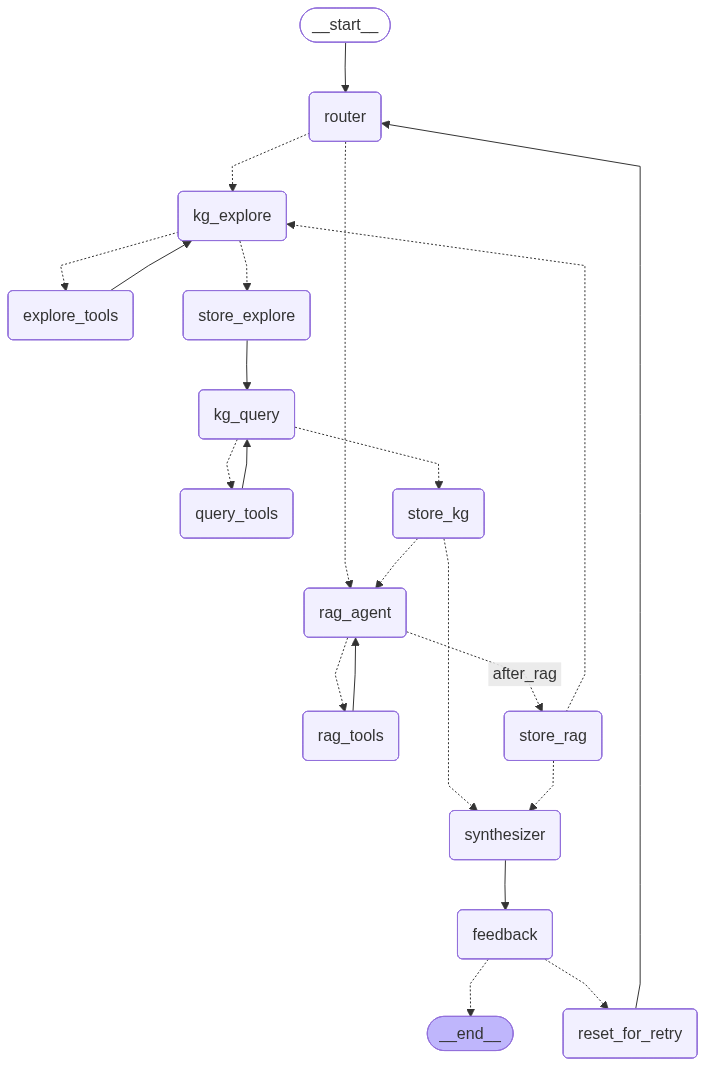

In [11]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

b = StateGraph(AgentState)

b.add_node("router",          router_node)
b.add_node("kg_explore",      kg_explore_node)
b.add_node("explore_tools",   ToolNode(explore_tools))
b.add_node("store_explore",   store_explore_result)
b.add_node("kg_query",        kg_query_node)
b.add_node("query_tools",     ToolNode(query_tools))
b.add_node("store_kg",        store_kg_result)
b.add_node("rag_agent",       rag_agent_node)
b.add_node("rag_tools",       ToolNode(rag_tools))
b.add_node("store_rag",       store_rag_result)
b.add_node("synthesizer",     synthesizer_node)
b.add_node("feedback",        feedback_node)
b.add_node("reset_for_retry", reset_for_retry)

b.add_edge(START, "router")
b.add_conditional_edges("router",       route_after_router,   {"kg_explore":"kg_explore","rag_agent":"rag_agent"})
b.add_conditional_edges("kg_explore",   kg_explore_condition, {"explore_tools":"explore_tools","store_explore":"store_explore"})
b.add_edge("explore_tools",  "kg_explore")
b.add_edge("store_explore",  "kg_query")
b.add_conditional_edges("kg_query",     kg_query_condition,   {"query_tools":"query_tools","store_kg":"store_kg"})
b.add_edge("query_tools",    "kg_query")
b.add_conditional_edges("store_kg",     route_after_kg,       {"rag_agent":"rag_agent","synthesizer":"synthesizer"})
b.add_conditional_edges("rag_agent",    rag_tools_condition,  {"rag_tools":"rag_tools","after_rag":"store_rag"})
b.add_edge("rag_tools",      "rag_agent")
b.add_conditional_edges("store_rag",    route_after_rag,      {"kg_explore":"kg_explore","synthesizer":"synthesizer"})
b.add_edge("synthesizer",    "feedback")
b.add_conditional_edges("feedback",     route_after_feedback, {"reset_for_retry":"reset_for_retry","__end__":END})
b.add_edge("reset_for_retry","router")

react_graph_memory = b.compile(checkpointer=MemorySaver())
display(Image(react_graph_memory.get_graph(xray=True).draw_mermaid_png()))


## 9. Run

In [12]:
from langchain_core.messages import HumanMessage, ToolMessage

config  = {"configurable": {"thread_id": "borrajas_011"}}
question = "How many fatalities were recorded on 29 May 2024 due to floods in Rio Grande do Sul?"

result = react_graph_memory.invoke(
    {"messages": [HumanMessage(content=question)],
     "order": "kg_first", "explore_summary": "", "sparql_result": "",
     "rag_result": "", "final_answer": "", "feedback_result": "negative",
     "feedback_count": 0,
     "explore_call_count": 0, "query_call_count": 0, "rag_call_count": 0},
    config
)

print("\n=== FINAL ANSWER ===")
print(result["final_answer"])
print(f"\nFeedback iterations : {result['feedback_count']}")
print(f"Final verdict       : {result['feedback_result']}")

tool_msgs = [m for m in result["messages"] if isinstance(m, ToolMessage)]
print(f"\nTools used ({len(tool_msgs)} total):")
for i, m in enumerate(tool_msgs, 1):
    print(f"  {i}. {m.name}")


[Router] rag_first
[RAG] Loading existing Chroma DB for source set 30caf3d2651a...


/var/folders/m5/_gg_c8dx3_7cl1gy0wn_kn6r0000gn/T/ipykernel_2144/4089925174.py:194: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  return Chroma(


[RAG] deterministic retrieval completed in 1 pass(es)
[RAG] done in 1 call(s): **Answer**

- The floods in Rio Grande do Sul caused **169 fatalities** on 29 May 2024 (with 44 peop...
[Explore] deterministic profile completed in 1 pass(es)
[Explore] done in 1 call(s): **KG Exploration Summary – Querying Flood‑Fatalities (29 May 2024 – Rio Grande do Sul)**  

---

###...
[KG Query] done in 2 call(s): The query returned a total of 0 fatalities for a flood event on 29 May 2024 in Rio Grande do Sul. Th...
[Synthesizer] attempt 1
[Feedback #1] POSITIVE — 
[Feedback]  accepted

=== FINAL ANSWER ===
{
  "short_answer": "169",
  "answer": "The floods in Rio Grande do Sul on 29 May 2024 resulted in 169 fatalities, according to the World Weather Attribution report. The KG dataset, however, records zero fatalities for that date, likely due to missing or differently represented data.",
  "kg_evidence": "The KG query returned a total of 0 fatalities for a flood event on 29 May 2024 in Rio Grande do 

In [13]:
print("\n=== CONVERSATION ===")
for m in result["messages"]:
    m.pretty_print()


=== CONVERSATION ===
================================ Human Message =================================

How many fatalities were recorded on 29 May 2024 due to floods in Rio Grande do Sul?
================================== Ai Message ==================================

**Answer**

- The floods in Rio Grande do Sul caused **169 fatalities** on 29 May 2024 (with 44 people still missing).  

**Citation**  
- World Weather Attribution, “Climate change, El Niño and infrastructure failures behind massive floods in southern Brazil,” 2024. Relevant passage: “…on the 29th of May, to 169 fatalities with 44 people still missing”【https://www.worldweatherattribution.org/climate-change-made-the-floods-in-southern-brazil-twice-as-likely/】.  

**Explanation**

The retrieved passage directly states the number of deaths recorded on the specified date, so the question is fully answered by the evidence. No additional inference is required.
================================== Ai Message ===================